# Cross-model validation notebook: UNet + YOLOv8 + PraNet + Polyp-PVT

This notebook extends your current workflow to evaluate **4 models** on **CVC-ClinicDB**:

- UNet
- YOLOv8 segmentation
- PraNet
- Polyp-PVT

It includes:

1. Dataset preparation.
2. Weight loading.
3. Per-image evaluation with segmentation metrics.
4. Model comparison.
5. Blind image-level analysis.
6. `OR_ALL`, `AND_ALL`, and `MAJORITY_3OF4` ensembles.
7. Export of CSV files and a ZIP archive with results.

> **Important:** this is a cross-validation / consensus analysis across models on the same test set.  
> It is **not** a `k-fold` retraining scheme.

In [ ]:
# 0. general setup

DATASET_SLUG = "balraj98/cvcclinicdb"

UNET_PT_PATH   = "/content/unet_polypdb_best.pt"
YOLO_SEG_PT_PATH = "/content/best_detection.pt"
PRANET_PT_PATH = "/content/PraNet-19.pth"
POLYPPVT_PT_PATH = "/content/polyp_pvt_real_like_best.pt"   # cámbialo si tu archivo está en otra ruta

IMG_SIZE = 256
BATCH_SIZE = 8


SEG_THRESHOLD = 0.5
YOLO_CONF = 0.25
MIN_AREA_PX = 50


EXPORT_PREFIX = "cvcclinicdb_4models"

print("Configured paths:")
print("UNET_PT_PATH     =", UNET_PT_PATH)
print("YOLO_SEG_PT_PATH =", YOLO_SEG_PT_PATH)
print("PRANET_PT_PATH   =", PRANET_PT_PATH)
print("POLYPPVT_PT_PATH =", POLYPPVT_PT_PATH)

Configured paths:
UNET_PT_PATH     = /content/unet_polypdb_best.pt
YOLO_SEG_PT_PATH = /content/best_detection.pt
PRANET_PT_PATH   = /content/PraNet-19.pth
POLYPPVT_PT_PATH = /content/polyp_pvt_real_like_best.pt


In [ ]:
# 1 .dependencies

!pip -q install kagglehub ultralytics timm einops

import os
import cv2
import json
import math
import shutil
import zipfile
import random
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
# 2. CVC-ClinicDB

path = kagglehub.dataset_download(DATASET_SLUG)
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cvcclinicdb' dataset.
Path to dataset files: /kaggle/input/cvcclinicdb


In [ ]:

# 3. Folders

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def find_cvc_folders(base_path):
    matches = []
    for root, dirs, files in os.walk(base_path):
        lower_map = {d.lower(): d for d in dirs}

        orig_name = None
        gt_name = None

        for cand in ["original", "images", "image"]:
            if cand in lower_map:
                orig_name = lower_map[cand]
                break

        for cand in ["ground truth", "groundtruth", "masks", "mask", "gt", "gtpolyp"]:
            if cand in lower_map:
                gt_name = lower_map[cand]
                break

        if orig_name and gt_name:
            orig_dir = os.path.join(root, orig_name)
            gt_dir = os.path.join(root, gt_name)
            if os.path.isdir(orig_dir) and os.path.isdir(gt_dir):
                matches.append((orig_dir, gt_dir))

    if not matches:
        raise FileNotFoundError(f"No image/mask folders found under: {base_path}")

    print("Candidate folders found:")
    for i, (a, b) in enumerate(matches):
        print(f"[{i}] images={a}")
        print(f"    masks ={b}")

    return matches[0]

orig_dir, gt_dir = find_cvc_folders(path)
print("Using:")
print(" images:", orig_dir)
print(" masks :", gt_dir)

Candidate folders found:
[0] images=/kaggle/input/cvcclinicdb/TIF/Original
    masks =/kaggle/input/cvcclinicdb/TIF/Ground Truth
[1] images=/kaggle/input/cvcclinicdb/PNG/Original
    masks =/kaggle/input/cvcclinicdb/PNG/Ground Truth
Using:
 images: /kaggle/input/cvcclinicdb/TIF/Original
 masks : /kaggle/input/cvcclinicdb/TIF/Ground Truth


In [ ]:

# 4. Normalization

normalized_root = "/content/cvcclinicdb_normalized"
images_dir = os.path.join(normalized_root, "images")
masks_dir  = os.path.join(normalized_root, "masks")
bbox_dir   = os.path.join(normalized_root, "bbox")

if os.path.exists(normalized_root):
    shutil.rmtree(normalized_root)

os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)
os.makedirs(bbox_dir, exist_ok=True)

def list_valid_files(folder):
    return sorted([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(VALID_EXTS)
    ])

def build_stem_map(folder):
    files = list_valid_files(folder)
    out = {}
    for f in files:
        stem = os.path.splitext(f)[0].strip()
        out[stem] = f
    return out

img_map = build_stem_map(orig_dir)
mask_map = build_stem_map(gt_dir)
common_stems = sorted(set(img_map) & set(mask_map))

print("Images :", len(img_map))
print("Masks  :", len(mask_map))
print("Paired :", len(common_stems))

for stem in common_stems:
    src_img = os.path.join(orig_dir, img_map[stem])
    src_msk = os.path.join(gt_dir, mask_map[stem])

    ext_img = os.path.splitext(img_map[stem])[1].lower()
    ext_msk = os.path.splitext(mask_map[stem])[1].lower()

    dst_img = os.path.join(images_dir, stem + ext_img)
    dst_msk = os.path.join(masks_dir, stem + ext_msk)

    shutil.copy2(src_img, dst_img)
    shutil.copy2(src_msk, dst_msk)

print("Normalized dataset saved to:", normalized_root)
print("Sample images:", sorted(os.listdir(images_dir))[:5])
print("Sample masks :", sorted(os.listdir(masks_dir))[:5])

Images : 612
Masks  : 612
Paired : 612
Normalized dataset saved to: /content/cvcclinicdb_normalized
Sample images: ['1.tif', '10.tif', '100.tif', '101.tif', '102.tif']
Sample masks : ['1.tif', '10.tif', '100.tif', '101.tif', '102.tif']


## Dataset class and metrics


In [ ]:
# 5. Dataset

import os
import glob
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 352
BATCH_SIZE = 8

def existing_dirs(cands):
    return [p for p in cands if os.path.isdir(p)]

def find_cvcclinicdb_pairs():
    candidates = []

    possible_roots = [
        "/kaggle/input/cvcclinicdb",
        "/content/cvcclinicdb",
        "/content/CVC-ClinicDB",
        "/content/CVCClinicDB",
        "/content/dataset",
        "/content/data",
        "/content/drive/MyDrive",
    ]

    for root in possible_roots:
        if not os.path.exists(root):
            continue

        tif_orig = os.path.join(root, "TIF", "Original")
        tif_mask = os.path.join(root, "TIF", "Ground Truth")
        png_orig = os.path.join(root, "PNG", "Original")
        png_mask = os.path.join(root, "PNG", "Ground Truth")

        if os.path.isdir(tif_orig) and os.path.isdir(tif_mask):
            candidates.append((tif_orig, tif_mask))
        if os.path.isdir(png_orig) and os.path.isdir(png_mask):
            candidates.append((png_orig, png_mask))


        for dirpath, dirnames, _ in os.walk(root):
            if os.path.basename(dirpath).lower() == "original":
                parent = os.path.dirname(dirpath)
                gt = os.path.join(parent, "Ground Truth")
                if os.path.isdir(gt):
                    candidates.append((dirpath, gt))


    unique = []
    seen = set()
    for img_dir, mask_dir in candidates:
        key = (os.path.abspath(img_dir), os.path.abspath(mask_dir))
        if key not in seen:
            seen.add(key)
            unique.append((img_dir, mask_dir))

    print("Candidate folders found:")
    for i, (img_dir, mask_dir) in enumerate(unique):
        print(f"[{i}] images={img_dir}")
        print(f"    masks ={mask_dir}")

    if not unique:
        raise FileNotFoundError("No se encontraron carpetas tipo Original / Ground Truth.")


    chosen = None
    for img_dir, mask_dir in unique:
        if "/TIF/" in img_dir.replace("\\", "/"):
            chosen = (img_dir, mask_dir)
            break
    if chosen is None:
        chosen = unique[0]

    print("\nUsing:")
    print(" images:", chosen[0])
    print(" masks :", chosen[1])
    return chosen

def list_image_files(folder):
    exts = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(files)

def build_pairs(images_dir, masks_dir):
    img_files = list_image_files(images_dir)
    mask_files = list_image_files(masks_dir)

    print("\nRaw counts:")
    print(" images:", len(img_files))
    print(" masks :", len(mask_files))

    img_map = {os.path.splitext(os.path.basename(f))[0]: f for f in img_files}
    mask_map = {os.path.splitext(os.path.basename(f))[0]: f for f in mask_files}

    common = sorted(set(img_map.keys()) & set(mask_map.keys()))
    print(" matched pairs:", len(common))

    if len(common) == 0:
        print("\nExample image names:")
        for x in list(img_map.keys())[:10]:
            print(" ", x)
        print("\nExample mask names:")
        for x in list(mask_map.keys())[:10]:
            print(" ", x)
        raise ValueError("No hay nombres coincidentes entre imágenes y máscaras.")

    return [(img_map[k], mask_map[k], k) for k in common]

class PolypEvalDataset(Dataset):
    def __init__(self, images_dir, masks_dir, img_size=352):
        self.img_size = img_size
        self.pairs = build_pairs(images_dir, masks_dir)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path, name = self.pairs[idx]

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Could not read image: {img_path}")
        if mask is None:
            raise ValueError(f"Could not read mask: {mask_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        img = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        img = np.transpose(img, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        return {
            "image": torch.tensor(img, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
            "name": name,
            "img_path": img_path,
            "mask_path": mask_path,
        }

IMAGES_DIR, MASKS_DIR = find_cvcclinicdb_pairs()

seg_dataset = PolypEvalDataset(IMAGES_DIR, MASKS_DIR, img_size=IMG_SIZE)
seg_loader = DataLoader(seg_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\nSegmentation samples:", len(seg_dataset))
sample = seg_dataset[0]
print("Image tensor:", sample["image"].shape, sample["image"].dtype)
print("Mask tensor :", sample["mask"].shape, sample["mask"].dtype)
print("Sample name :", sample["name"])

Candidate folders found:
[0] images=/kaggle/input/cvcclinicdb/TIF/Original
    masks =/kaggle/input/cvcclinicdb/TIF/Ground Truth
[1] images=/kaggle/input/cvcclinicdb/PNG/Original
    masks =/kaggle/input/cvcclinicdb/PNG/Ground Truth

Using:
 images: /kaggle/input/cvcclinicdb/TIF/Original
 masks : /kaggle/input/cvcclinicdb/TIF/Ground Truth

Raw counts:
 images: 612
 masks : 612
 matched pairs: 612

Segmentation samples: 612
Image tensor: torch.Size([3, 352, 352]) torch.float32
Mask tensor : torch.Size([1, 352, 352]) torch.float32
Sample name : 1


In [ ]:

# 6. Metrics helpers
def segmentation_metrics_from_masks(pred, gt, eps=1e-7):
    pred = pred.astype(np.uint8)
    gt   = gt.astype(np.uint8)

    tp = int(np.sum((pred == 1) & (gt == 1)))
    tn = int(np.sum((pred == 0) & (gt == 0)))
    fp = int(np.sum((pred == 1) & (gt == 0)))
    fn = int(np.sum((pred == 0) & (gt == 1)))

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    accuracy = (tp + tn + eps) / (tp + tn + fp + fn + eps)

    gt_area = int(gt.sum())
    pred_area = int(pred.sum())
    detected_real_percent = 100.0 * tp / (gt_area + eps)
    wrong_polyp_percent   = 100.0 * fp / (pred_area + eps) if pred_area > 0 else 0.0
    true_polyp_percent    = 100.0 * tp / (pred_area + eps) if pred_area > 0 else 0.0

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "accuracy": float(accuracy),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "gt_area_px": gt_area,
        "pred_area_px": pred_area,
        "detected_real_percent": float(detected_real_percent),
        "wrong_polyp_percent": float(wrong_polyp_percent),
        "true_polyp_percent": float(true_polyp_percent),
    }

def summarize_segmentation_df(df):
    if df.empty:
        return {}
    cols = [
        "dice", "iou", "precision", "recall", "accuracy",
        "detected_real_percent", "wrong_polyp_percent", "true_polyp_percent"
    ]
    return df[cols].mean(numeric_only=True).to_dict()

def find_mask_path(masks_dir, image_name):
    stem = os.path.splitext(image_name)[0]
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
        p = os.path.join(masks_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None

def gt_image_label_from_mask(mask_path, min_area_px=1):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return np.nan
    mask_bin = (mask > 127).astype(np.uint8)
    area = int(mask_bin.sum())
    return int(area >= min_area_px)

def image_level_confusion(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    f1 = 2 * precision * recall / (precision + recall + 1e-7)

    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "precision": precision, "recall": recall,
        "specificity": specificity, "accuracy": accuracy, "f1": f1
    }

def resize_binary_mask(mask, target_hw):
    h, w = target_hw
    mask = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
    return (mask > 0).astype(np.uint8)

## UNet

In [ ]:
# 7. load UNet

class DoubleConvGN(nn.Module):
    def __init__(self, in_ch, out_ch, groups=8, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNetImproved(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        self.d1 = DoubleConvGN(in_ch, base)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConvGN(base, base * 2)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConvGN(base * 2, base * 4)
        self.p3 = nn.MaxPool2d(2)

        self.b = DoubleConvGN(base * 4, base * 8, dropout=0.2)

        self.u3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.c3 = DoubleConvGN(base * 8 + base * 4, base * 4)

        self.u2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.c2 = DoubleConvGN(base * 4 + base * 2, base * 2)

        self.u1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.c1 = DoubleConvGN(base * 2 + base, base)

        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))
        xb = self.b(self.p3(x3))

        x = self.u3(xb)
        x = torch.cat([x, x3], dim=1)
        x = self.c3(x)

        x = self.u2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.c2(x)

        x = self.u1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.c1(x)

        return self.out(x)

def load_unet_checkpoint(path, device):
    model = UNetImproved(in_ch=3, out_ch=1, base=32).to(device)
    ckpt = torch.load(path, map_location=device)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict):
        state = ckpt
    else:
        raise ValueError("Unsupported UNet checkpoint format")

    model.load_state_dict(state, strict=True)
    model.eval()
    return model, ckpt

unet_model, unet_ckpt = load_unet_checkpoint(UNET_PT_PATH, device)
print("UNet loaded correctly.")

UNet loaded correctly.


In [ ]:


# 8. UNet Evaluation

def evaluate_torch_model(model, loader, threshold=0.5, output_selector="single", model_name="model"):
    rows = []
    model.eval()

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {model_name}"):
            imgs = batch["image"].to(device)
            gts  = batch["mask"].cpu().numpy()

            outputs = model(imgs)

            if output_selector == "single":
                logits = outputs
            elif output_selector == "first":
                logits = outputs[0]
            elif output_selector == "last":
                logits = outputs[-1]
            else:
                raise ValueError(f"Unknown output_selector={output_selector}")

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(np.uint8)

            for i in range(len(batch["name"])):
                pred_mask = preds[i, 0]
                gt_mask   = gts[i, 0].astype(np.uint8)

                metrics = segmentation_metrics_from_masks(pred_mask, gt_mask)
                metrics["pred_mask"] = pred_mask.copy()
                metrics["image"] = batch["name"][i]
                rows.append(metrics)

    df = pd.DataFrame(rows)
    summary = summarize_segmentation_df(df)
    return df, summary

unet_df, unet_summary = evaluate_torch_model(
    unet_model, seg_loader, threshold=SEG_THRESHOLD, output_selector="single", model_name="UNet"
)

print("UNet summary:")
display(pd.DataFrame([unet_summary]))

Evaluating UNet: 100%|██████████| 77/77 [00:01<00:00, 45.90it/s]

UNet summary:


,dice,iou,precision,recall,accuracy,detected_real_percent,wrong_polyp_percent,true_polyp_percent
0,0.628485,0.519255,0.756067,0.600703,0.943071,60.070305,24.393262,75.606738


## YOLOv8 Segmentation

In [ ]:

# 9. load and evaluation (YOLOv8-Seg)

from ultralytics import YOLO
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

yolo_model = YOLO(YOLO_SEG_PT_PATH)

def find_mask_path(masks_dir, img_name):
    stem = os.path.splitext(img_name)[0]
    exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]
    for ext in exts:
        candidate = os.path.join(masks_dir, stem + ext)
        if os.path.exists(candidate):
            return candidate
    return None

def evaluate_yolo_segmentation(yolo_model, images_dir, masks_dir, conf=0.25):
    rows = []

    image_names = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"))
    ])

    print("Images found for YOLO eval:", len(image_names))
    print("First 10:", image_names[:10])

    for img_name in tqdm(image_names, desc="Evaluating YOLO-Seg"):
        img_path = os.path.join(images_dir, img_name)
        gt_mask_path = find_mask_path(masks_dir, img_name)

        if gt_mask_path is None:
            print(f"Skipping {img_name}: mask not found")
            continue

        img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"Skipping {img_name}: image could not be read")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        gt_mask = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE)
        if gt_mask is None:
            print(f"Skipping {img_name}: mask could not be read")
            continue

        gt_mask = cv2.resize(gt_mask, (w, h), interpolation=cv2.INTER_NEAREST)
        gt_mask = (gt_mask > 127).astype(np.uint8)

        results = yolo_model.predict(img_rgb, conf=conf, verbose=False)
        result = results[0]

        pred_mask = np.zeros((h, w), dtype=np.uint8)
        if result.masks is not None and len(result.masks.data) > 0:
            masks_tensor = result.masks.data.cpu().numpy()
            merged = np.any(masks_tensor > 0.5, axis=0).astype(np.uint8)
            pred_mask = cv2.resize(merged, (w, h), interpolation=cv2.INTER_NEAREST)

        pred_eval = resize_binary_mask(pred_mask, (IMG_SIZE, IMG_SIZE))
        gt_eval   = resize_binary_mask(gt_mask, (IMG_SIZE, IMG_SIZE))

        metrics = segmentation_metrics_from_masks(pred_eval, gt_eval)
        metrics["pred_mask"] = pred_eval.copy()
        metrics["image"] = img_name
        rows.append(metrics)

    df = pd.DataFrame(rows)
    summary = summarize_segmentation_df(df)
    return df, summary

yolo_seg_df, yolo_seg_summary = evaluate_yolo_segmentation(
    yolo_model, images_dir, masks_dir, conf=YOLO_CONF
)

print("YOLO-Seg summary:")
display(pd.DataFrame([yolo_seg_summary]))

Images found for YOLO eval: 612
First 10: ['1.tif', '10.tif', '100.tif', '101.tif', '102.tif', '103.tif', '104.tif', '105.tif', '106.tif', '107.tif']


Evaluating YOLO-Seg: 100%|██████████| 612/612 [00:02<00:00, 247.26it/s]

YOLO-Seg summary:


,dice,iou,precision,recall,accuracy,detected_real_percent,wrong_polyp_percent,true_polyp_percent
0,0.77351,0.685754,0.87345,0.766639,0.965196,76.663928,12.654981,81.952862


## PraNet

In [ ]:


# 10. PraNet
PRANET_REPO_DIR = "/content/PraNet"

if not os.path.exists(PRANET_REPO_DIR):
    !git clone https://github.com/DengPingFan/PraNet.git /content/PraNet

# Patch del archivo Res2Net_v1b.py con la versión corregida
from pathlib import Path

fixed_res2net_code = r'''
import torch
import torch.nn as nn
import math
import torch.utils.model_zoo as model_zoo

__all__ = ['Res2Net', 'res2net50_v1b', 'res2net101_v1b', 'res2net50_v1b_26w_4s',
           'res2net101_v1b_26w_4s', 'res2net152_v1b_26w_4s']

model_urls = {
    'res2net50_v1b_26w_4s': 'https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_v1b_26w_4s-3cf99910.pth',
    'res2net101_v1b_26w_4s': 'https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net101_v1b_26w_4s-0812c246.pth',
    'res2net152_v1b_26w_4s': 'https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net152_v1b_26w_4s-7c7c9dee.pth',
}

class Bottle2neck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, baseWidth=26, scale=4, stype='normal'):
        super(Bottle2neck, self).__init__()
        width = int(math.floor(planes * (baseWidth / 64.0)))
        self.conv1 = nn.Conv2d(inplanes, width * scale, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width * scale)

        if scale == 1:
            self.nums = 1
        else:
            self.nums = scale - 1

        if stype == 'stage':
            self.pool = nn.AvgPool2d(kernel_size=3, stride=stride, padding=1)

        convs = []
        bns = []
        for i in range(self.nums):
            convs.append(nn.Conv2d(width, width, kernel_size=3, stride=stride, padding=1, bias=False))
            bns.append(nn.BatchNorm2d(width))
        self.convs = nn.ModuleList(convs)
        self.bns = nn.ModuleList(bns)

        self.conv3 = nn.Conv2d(width * scale, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stype = stype
        self.scale = scale
        self.width = width
        self.stride = stride

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        spx = torch.split(out, self.width, 1)
        for i in range(self.nums):
            if i == 0 or self.stype == 'stage':
                sp = spx[i]
            else:
                sp = sp + spx[i]
            sp = self.convs[i](sp)
            sp = self.relu(self.bns[i](sp))
            if i == 0:
                out_ = sp
            else:
                out_ = torch.cat((out_, sp), 1)

        if self.scale != 1 and self.stype == 'normal':
            out_ = torch.cat((out_, spx[self.nums]), 1)
        elif self.scale != 1 and self.stype == 'stage':
            out_ = torch.cat((out_, self.pool(spx[self.nums])), 1)

        out = self.conv3(out_)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)
        return out

class Res2Net(nn.Module):
    def __init__(self, block, layers, baseWidth=26, scale=4, num_classes=1000):
        self.inplanes = 64
        super(Res2Net, self).__init__()
        self.baseWidth = baseWidth
        self.scale = scale

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 1, 1, bias=False)
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.AvgPool2d(kernel_size=stride, stride=stride, ceil_mode=True, count_include_pad=False),
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample=downsample,
                            stype='stage', baseWidth=self.baseWidth, scale=self.scale))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes, baseWidth=self.baseWidth, scale=self.scale))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def _safe_load(model, url, pretrained=False):
    if pretrained:
        try:
            state_dict = model_zoo.load_url(url)
            model.load_state_dict(state_dict)
            print(f"Loaded pretrained weights from: {url}")
        except Exception as e:
            print(f"Warning: pretrained weights could not be loaded: {e}")
            print("Continuing with random initialization.")
    return model

def res2net50_v1b(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 6, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net50_v1b_26w_4s'], pretrained=pretrained)

def res2net101_v1b(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 23, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net101_v1b_26w_4s'], pretrained=pretrained)

def res2net50_v1b_26w_4s(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 6, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net50_v1b_26w_4s'], pretrained=pretrained)

def res2net101_v1b_26w_4s(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 23, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net101_v1b_26w_4s'], pretrained=pretrained)

def res2net152_v1b_26w_4s(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 8, 36, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net152_v1b_26w_4s'], pretrained=pretrained)
'''

target = Path("/content/PraNet/lib/Res2Net_v1b.py")
target.write_text(fixed_res2net_code, encoding="utf-8")
print("Rewritten:", target)

import sys
if PRANET_REPO_DIR not in sys.path:
    sys.path.append(PRANET_REPO_DIR)
    sys.path.append(os.path.join(PRANET_REPO_DIR, "lib"))

from lib.PraNet_Res2Net import PraNet

pranet_model = PraNet().to(device)
pranet_ckpt = torch.load(PRANET_PT_PATH, map_location=device)

if isinstance(pranet_ckpt, dict) and "model_state_dict" in pranet_ckpt:
    pranet_state = pranet_ckpt["model_state_dict"]
else:
    pranet_state = pranet_ckpt

pranet_model.load_state_dict(pranet_state, strict=False)
pranet_model.eval()
print("PraNet loaded correctly.")

Rewritten: /content/PraNet/lib/Res2Net_v1b.py
Loaded pretrained weights from: https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_v1b_26w_4s-3cf99910.pth
PraNet loaded correctly.


In [ ]:


# 11. PraNet evaluation

pranet_df, pranet_summary = evaluate_torch_model(
    pranet_model, seg_loader, threshold=SEG_THRESHOLD, output_selector="first", model_name="PraNet"
)

print("PraNet summary:")
display(pd.DataFrame([pranet_summary]))

Evaluating PraNet: 100%|██████████| 77/77 [00:01<00:00, 46.63it/s]

PraNet summary:


,dice,iou,precision,recall,accuracy,detected_real_percent,wrong_polyp_percent,true_polyp_percent
0,0.716369,0.635076,0.69034,0.883167,0.92127,88.316653,30.966021,68.380384


## Polyp-PVT

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class BasicConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0, dilation=1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_ch, out_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
            bias=False
        )
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class Reduction(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = BasicConv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.block(x)

class CFM(nn.Module):
    def __init__(self, channel=32):
        super().__init__()
        self.conv_upsample1 = BasicConv2d(channel, channel, 3, padding=1)
        self.conv_upsample2 = BasicConv2d(channel, channel, 3, padding=1)
        self.conv_upsample3 = BasicConv2d(channel, channel, 3, padding=1)
        self.conv_concat2 = BasicConv2d(channel * 2, channel * 2, 3, padding=1)
        self.conv_concat3 = BasicConv2d(channel * 4, channel * 4, 3, padding=1)
        self.conv_out = BasicConv2d(channel * 4, channel, 3, padding=1)

    def forward(self, x4, x3, x2):
        x4_up = F.interpolate(self.conv_upsample1(x4), size=x3.shape[2:], mode="bilinear", align_corners=False)
        x3_f = x4_up * x3
        x3_up = F.interpolate(self.conv_upsample2(x3_f), size=x2.shape[2:], mode="bilinear", align_corners=False)
        x4_up2 = F.interpolate(self.conv_upsample3(x4), size=x2.shape[2:], mode="bilinear", align_corners=False)
        x2_f = x3_up * x2 * x4_up2
        x3_cat = torch.cat([F.interpolate(x4, size=x3.shape[2:], mode="bilinear", align_corners=False), x3_f], dim=1)
        x3_cat = self.conv_concat2(x3_cat)
        x2_cat = torch.cat([F.interpolate(x3_cat, size=x2.shape[2:], mode="bilinear", align_corners=False), x2_f, x2], dim=1)
        x2_cat = self.conv_concat3(x2_cat)
        return self.conv_out(x2_cat)

class CIM(nn.Module):
    def __init__(self, low_ch, channel=32):
        super().__init__()
        self.low_proj = BasicConv2d(low_ch, channel, 1)
        self.fuse = nn.Sequential(
            BasicConv2d(channel * 2, channel, 3, padding=1),
            BasicConv2d(channel, channel, 3, padding=1),
        )

    def forward(self, low_feat, high_feat):
        low_feat = self.low_proj(low_feat)
        high_up = F.interpolate(high_feat, size=low_feat.shape[2:], mode="bilinear", align_corners=False)
        return self.fuse(torch.cat([low_feat, high_up], dim=1))

class SAM(nn.Module):
    def __init__(self, channel=32):
        super().__init__()
        self.conv1 = BasicConv2d(channel + 1, channel, 3, padding=1)
        self.conv2 = BasicConv2d(channel, channel, 3, padding=1)
        self.out = nn.Conv2d(channel, channel, 1)

    def forward(self, feat, coarse_pred):
        coarse_prob = torch.sigmoid(coarse_pred)
        coarse_prob = F.interpolate(coarse_prob, size=feat.shape[2:], mode="bilinear", align_corners=False)
        x = self.conv1(torch.cat([feat, coarse_prob], dim=1))
        x = self.conv2(x)
        att = torch.sigmoid(self.out(x))
        return feat * att + feat

class PredHead(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.head = nn.Conv2d(in_ch, 1, kernel_size=1)

    def forward(self, x, out_size):
        x = self.head(x)
        return F.interpolate(x, size=out_size, mode="bilinear", align_corners=False)


# 2. main class Polyp-PVT


class PolypPVT_RealLike(nn.Module):
    def __init__(self, channel=32, backbone_name="pvt_v2_b2"):
        super().__init__()
        # Inicialización aleatoria (sin internet)
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        feat_channels = self.backbone.feature_info.channels()
        print(f"Backbone {backbone_name} inicializado con pesos aleatorios. Canales: {feat_channels}")

        c1, c2, c3, c4 = feat_channels

        self.reduce_x2 = Reduction(c2, channel)
        self.reduce_x3 = Reduction(c3, channel)
        self.reduce_x4 = Reduction(c4, channel)

        self.cfm = CFM(channel=channel)
        self.cim = CIM(low_ch=c1, channel=channel)
        self.sam = SAM(channel=channel)

        self.pred_coarse = PredHead(channel)
        self.pred_final = PredHead(channel)

    def forward(self, x):
        out_size = x.shape[2:]
        feats = self.backbone(x)
        x1, x2, x3, x4 = feats

        x2_r = self.reduce_x2(x2)
        x3_r = self.reduce_x3(x3)
        x4_r = self.reduce_x4(x4)

        cfm_feat = self.cfm(x4_r, x3_r, x2_r)
        cim_feat = self.cim(x1, cfm_feat)

        pred1 = self.pred_coarse(cfm_feat, out_size)
        sam_feat = self.sam(cim_feat, pred1)
        pred2 = self.pred_final(sam_feat, out_size)

        return pred1, pred2




polyppvt_model = PolypPVT_RealLike(channel=32).to(device)

polyppvt_ckpt = torch.load(POLYPPVT_PT_PATH, map_location=device)
polyppvt_state = polyppvt_ckpt["model_state_dict"] if isinstance(polyppvt_ckpt, dict) and "model_state_dict" in polyppvt_ckpt else polyppvt_ckpt

polyppvt_model.load_state_dict(polyppvt_state, strict=False)
polyppvt_model.eval()

print("Polyp-PVT cargado correctamente.")

Backbone pvt_v2_b2 inicializado con pesos aleatorios. Canales: [64, 128, 320, 512]
Polyp-PVT cargado correctamente.


In [ ]:


# 13.  Polyp-PVT evaluation

polyppvt_df, polyppvt_summary = evaluate_torch_model(
    polyppvt_model, seg_loader, threshold=SEG_THRESHOLD, output_selector="last", model_name="Polyp-PVT"
)

print("Polyp-PVT summary:")
display(pd.DataFrame([polyppvt_summary]))

Evaluating Polyp-PVT: 100%|██████████| 77/77 [00:03<00:00, 25.53it/s]

Polyp-PVT summary:


,dice,iou,precision,recall,accuracy,detected_real_percent,wrong_polyp_percent,true_polyp_percent
0,0.825032,0.75395,0.870525,0.827806,0.971641,82.780625,12.947526,87.052474


## Comparación de los 4 modelos

In [ ]:


# 14. metrics

comparison_seg = pd.DataFrame([
    {"model": "UNet", **unet_summary},
    {"model": "YOLO-Seg", **yolo_seg_summary},
    {"model": "PraNet", **pranet_summary},
    {"model": "Polyp-PVT", **polyppvt_summary},
])

comparison_seg = comparison_seg.sort_values(by="dice", ascending=False).reset_index(drop=True)
comparison_seg.to_csv(f"{EXPORT_PREFIX}_comparison_segmentation.csv", index=False)
comparison_seg

,model,dice,iou,precision,recall,accuracy,detected_real_percent,wrong_polyp_percent,true_polyp_percent
0,Polyp-PVT,0.825032,0.753950,0.870525,0.827806,0.971641,82.780625,12.947526,87.052474
1,YOLO-Seg,0.773510,0.685754,0.873450,0.766639,0.965196,76.663928,12.654981,81.952862
2,PraNet,0.716369,0.635076,0.690340,0.883167,0.921270,88.316653,30.966021,68.380384
3,UNet,0.628485,0.519255,0.756067,0.600703,0.943071,60.070305,24.393262,75.606738


In [ ]:


# 15. save images

unet_df.to_csv(f"{EXPORT_PREFIX}_unet_per_image.csv", index=False)
pd.DataFrame([unet_summary]).to_csv(f"{EXPORT_PREFIX}_unet_summary.csv", index=False)

yolo_seg_df.to_csv(f"{EXPORT_PREFIX}_yolov8seg_per_image.csv", index=False)
pd.DataFrame([yolo_seg_summary]).to_csv(f"{EXPORT_PREFIX}_yolov8seg_summary.csv", index=False)

pranet_df.to_csv(f"{EXPORT_PREFIX}_pranet_per_image.csv", index=False)
pd.DataFrame([pranet_summary]).to_csv(f"{EXPORT_PREFIX}_pranet_summary.csv", index=False)

polyppvt_df.to_csv(f"{EXPORT_PREFIX}_polyppvt_per_image.csv", index=False)
pd.DataFrame([polyppvt_summary]).to_csv(f"{EXPORT_PREFIX}_polyppvt_summary.csv", index=False)

print("Per-image and summary CSVs saved.")

Per-image and summary CSVs saved.


## Blind analysis

In [ ]:
print("UNet sample names:", unet_df["image"].head(10).tolist())
print("YOLO sample names:", yolo_seg_df["image"].head(10).tolist())
print("PraNet sample names:", pranet_df["image"].head(10).tolist())
print("PolypPVT sample names:", polyppvt_df["image"].head(10).tolist())

UNet sample names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
YOLO sample names: ['1.tif', '10.tif', '100.tif', '101.tif', '102.tif', '103.tif', '104.tif', '105.tif', '106.tif', '107.tif']
PraNet sample names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
PolypPVT sample names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']


In [ ]:

# 16.  labels

import os
import cv2
import numpy as np
import pandas as pd

def normalize_image_name(x):
    x = str(x).strip()
    x = os.path.basename(x)
    x = os.path.splitext(x)[0]
    return x

def ensure_pred_area_px(df):
    df = df.copy()
    if "pred_area_px" not in df.columns:
        if "pred_mask" in df.columns:
            df["pred_area_px"] = df["pred_mask"].apply(
                lambda m: int(np.sum(np.array(m) > 0)) if m is not None else 0
            )
        else:
            raise ValueError("Missing both 'pred_area_px' and 'pred_mask'.")
    return df

def image_pred_from_df(df, model_name, min_area_px=50):
    df = ensure_pred_area_px(df).copy()
    df["image"] = df["image"].apply(normalize_image_name)

    out = df[["image", "pred_area_px"]].copy()
    out[model_name] = (out["pred_area_px"] >= min_area_px).astype(int)

    # Si hubiera duplicados por imagen, quedarse con el máximo
    out = out.groupby("image", as_index=False)[model_name].max()
    return out

def find_mask_path(masks_dir, img_name):
    stem = normalize_image_name(img_name)
    exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]
    for ext in exts:
        p = os.path.join(masks_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None

def gt_image_label_from_mask(mask_path, min_area_px=1):
    if mask_path is None or not os.path.exists(mask_path):
        return 0
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return 0
    mask = (mask > 127).astype(np.uint8)
    return int(mask.sum() >= min_area_px)

unet_img = image_pred_from_df(unet_df, "UNet", min_area_px=MIN_AREA_PX)
yolo_img = image_pred_from_df(yolo_seg_df, "YOLO", min_area_px=MIN_AREA_PX)
pranet_img = image_pred_from_df(pranet_df, "PraNet", min_area_px=MIN_AREA_PX)
polyppvt_img = image_pred_from_df(polyppvt_df, "PolypPVT", min_area_px=MIN_AREA_PX)

print("UNet sample names:", unet_img["image"].head(10).tolist())
print("YOLO sample names:", yolo_img["image"].head(10).tolist())
print("PraNet sample names:", pranet_img["image"].head(10).tolist())
print("PolypPVT sample names:", polyppvt_img["image"].head(10).tolist())

base_images = sorted(
    set(unet_img["image"]) &
    set(yolo_img["image"]) &
    set(pranet_img["image"]) &
    set(polyppvt_img["image"])
)

print("Common images across all 4 models:", len(base_images))

blind_df = pd.DataFrame({"image": base_images})
blind_df = blind_df.merge(unet_img, on="image", how="left")
blind_df = blind_df.merge(yolo_img, on="image", how="left")
blind_df = blind_df.merge(pranet_img, on="image", how="left")
blind_df = blind_df.merge(polyppvt_img, on="image", how="left")

for col in ["UNet", "YOLO", "PraNet", "PolypPVT"]:
    blind_df[col] = blind_df[col].fillna(0).astype(int)

blind_df["gt"] = blind_df["image"].apply(
    lambda x: gt_image_label_from_mask(find_mask_path(masks_dir, x), min_area_px=1)
)

blind_df["OR_ALL"] = (
    (blind_df["UNet"] == 1) |
    (blind_df["YOLO"] == 1) |
    (blind_df["PraNet"] == 1) |
    (blind_df["PolypPVT"] == 1)
).astype(int)

blind_df["AND_ALL"] = (
    (blind_df["UNet"] == 1) &
    (blind_df["YOLO"] == 1) &
    (blind_df["PraNet"] == 1) &
    (blind_df["PolypPVT"] == 1)
).astype(int)

blind_df["SUM_POS"] = blind_df[["UNet", "YOLO", "PraNet", "PolypPVT"]].sum(axis=1)
blind_df["MAJORITY_3OF4"] = (blind_df["SUM_POS"] >= 3).astype(int)

print("blind_df shape:", blind_df.shape)
display(blind_df.head())

UNet sample names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
YOLO sample names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
PraNet sample names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
PolypPVT sample names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
Common images across all 4 models: 612
blind_df shape: (612, 10)


,image,UNet,YOLO,PraNet,PolypPVT,gt,OR_ALL,AND_ALL,SUM_POS,MAJORITY_3OF4
0,1,1,1,1,1,1,1,1,4,1
1,10,1,1,1,1,1,1,1,4,1
2,100,1,1,1,1,1,1,1,4,1
3,101,1,1,1,1,1,1,1,4,1
4,102,1,1,1,1,1,1,1,4,1


In [ ]:


# 17. Metrics

rows = []
for col in ["UNet", "YOLO", "PraNet", "PolypPVT", "OR_ALL", "AND_ALL", "MAJORITY_3OF4"]:
    rows.append({"model": col, **image_level_confusion(blind_df["gt"], blind_df[col])})

blind_summary = pd.DataFrame(rows)
blind_summary.to_csv(f"{EXPORT_PREFIX}_blind_summary.csv", index=False)

print("📈 Métricas:")
blind_summary

📈 Métricas:


,model,tp,tn,fp,fn,precision,recall,specificity,accuracy,f1
0,UNet,610,0,0,2,1.0,0.996732,0.0,0.996732,0.998363
1,YOLO,579,0,0,33,1.0,0.946078,0.0,0.946078,0.972292
2,PraNet,607,0,0,5,1.0,0.991830,0.0,0.991830,0.995898
3,PolypPVT,612,0,0,0,1.0,1.000000,0.0,1.000000,1.000000
4,OR_ALL,612,0,0,0,1.0,1.000000,0.0,1.000000,1.000000
5,AND_ALL,575,0,0,37,1.0,0.939542,0.0,0.939542,0.968829
6,MAJORITY_3OF4,609,0,0,3,1.0,0.995098,0.0,0.995098,0.997543


In [ ]:

# 18. Counting

blind_df["pattern"] = blind_df.apply(
    lambda r: f"UNet({r['UNet']})_YOLO({r['YOLO']})_PraNet({r['PraNet']})_PolypPVT({r['PolypPVT']})",
    axis=1
)

blind_counts = blind_df["pattern"].value_counts().reset_index()
blind_counts.columns = ["case", "count"]

blind_counts.to_csv(f"{EXPORT_PREFIX}_blind_counts.csv", index=False)
blind_df.to_csv(f"{EXPORT_PREFIX}_blind_per_image.csv", index=False)

print("📊 Conteo:")
blind_counts

📊 Conteo:


,case,count
0,UNet(1)_YOLO(1)_PraNet(1)_PolypPVT(1),575
1,UNet(1)_YOLO(0)_PraNet(1)_PolypPVT(1),30
2,UNet(1)_YOLO(0)_PraNet(0)_PolypPVT(1),3
3,UNet(1)_YOLO(1)_PraNet(0)_PolypPVT(1),2
4,UNet(0)_YOLO(1)_PraNet(1)_PolypPVT(1),2


## Evaluación de área para ensambles

In [ ]:

# 19. masks: OR, AND, MAJORITY_3OF4

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

def normalize_image_name(x):
    x = str(x).strip()
    x = os.path.basename(x)
    x = os.path.splitext(x)[0]
    return x

def build_pred_mask_lookup(df):
    if "image" not in df.columns or "pred_mask" not in df.columns:
        raise ValueError("Each dataframe must contain 'image' and 'pred_mask' columns.")

    lut = {}
    for _, row in df.iterrows():
        key = normalize_image_name(row["image"])
        lut[key] = row["pred_mask"]
    return lut

def find_mask_path(masks_dir, img_name):
    stem = normalize_image_name(img_name)
    exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]
    for ext in exts:
        p = os.path.join(masks_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None


unet_lut = build_pred_mask_lookup(unet_df)
yolo_lut = build_pred_mask_lookup(yolo_seg_df)
pranet_lut = build_pred_mask_lookup(pranet_df)
polyppvt_lut = build_pred_mask_lookup(polyppvt_df)

ensemble_rows = []
skipped_missing_mask = 0
skipped_missing_pred = 0

for img_name in tqdm(blind_df["image"], desc="Evaluating ensembles"):
    key = normalize_image_name(img_name)

    mask_path = find_mask_path(masks_dir, key)
    if mask_path is None:
        skipped_missing_mask += 1
        continue

    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if gt_mask is None:
        skipped_missing_mask += 1
        continue

    gt_mask = cv2.resize(gt_mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    gt_mask = (gt_mask > 127).astype(np.uint8)

    u = unet_lut.get(key, None)
    y = yolo_lut.get(key, None)
    p = pranet_lut.get(key, None)
    v = polyppvt_lut.get(key, None)

    if any(x is None for x in [u, y, p, v]):
        skipped_missing_pred += 1
        continue

    u = (np.array(u) > 0).astype(np.uint8)
    y = (np.array(y) > 0).astype(np.uint8)
    p = (np.array(p) > 0).astype(np.uint8)
    v = (np.array(v) > 0).astype(np.uint8)

    if u.shape != (IMG_SIZE, IMG_SIZE):
        u = cv2.resize(u, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    if y.shape != (IMG_SIZE, IMG_SIZE):
        y = cv2.resize(y, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    if p.shape != (IMG_SIZE, IMG_SIZE):
        p = cv2.resize(p, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    if v.shape != (IMG_SIZE, IMG_SIZE):
        v = cv2.resize(v, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    votes = u + y + p + v
    pred_or  = (votes >= 1).astype(np.uint8)
    pred_and = (votes == 4).astype(np.uint8)
    pred_maj = (votes >= 3).astype(np.uint8)

    for name, pred in [
        ("OR_ALL", pred_or),
        ("AND_ALL", pred_and),
        ("MAJORITY_3OF4", pred_maj),
    ]:
        metrics = segmentation_metrics_from_masks(pred, gt_mask)
        metrics["image"] = key
        metrics["model"] = name
        metrics["pred_mask"] = pred.copy()
        ensemble_rows.append(metrics)

ensemble_df = pd.DataFrame(ensemble_rows)

print("Ensemble rows:", len(ensemble_df))
print("Skipped missing GT mask:", skipped_missing_mask)
print("Skipped missing predicted mask:", skipped_missing_pred)

if len(ensemble_df) == 0:
    raise ValueError(
        "ensemble_df is empty. Check that all model dataframes contain compatible 'image' names and 'pred_mask'."
    )

ensemble_df.to_csv(f"{EXPORT_PREFIX}_ensemble_per_image.csv", index=False)

required_cols = [
    "dice", "iou", "precision", "recall", "accuracy",
    "detected_real_percent", "wrong_polyp_percent", "true_polyp_percent"
]

missing_cols = [c for c in required_cols if c not in ensemble_df.columns]
if missing_cols:
    raise ValueError(f"Missing expected metric columns in ensemble_df: {missing_cols}")

ensemble_summary = (
    ensemble_df.groupby("model")[required_cols]
    .mean()
    .reset_index()
)

ensemble_summary.to_csv(f"{EXPORT_PREFIX}_ensemble_summary.csv", index=False)
display(ensemble_summary)

Evaluating ensembles: 100%|██████████| 612/612 [00:00<00:00, 1007.63it/s]


Ensemble rows: 1836
Skipped missing GT mask: 0
Skipped missing predicted mask: 0


,model,dice,iou,precision,recall,accuracy,detected_real_percent,wrong_polyp_percent,true_polyp_percent
0,AND_ALL,0.603757,0.505629,0.966752,0.511372,0.950905,51.137195,3.324832,86.054253
1,MAJORITY_3OF4,0.789914,0.716113,0.930262,0.749635,0.969960,74.963472,6.973795,90.085028
2,OR_ALL,0.694992,0.591368,0.614284,0.954210,0.909879,95.421023,38.571593,61.428407


In [ ]:

# 20. Visualization

import pandas as pd

models_df = pd.DataFrame([
    {"model": "Polyp-PVT", **polyppvt_summary},
    {"model": "YOLO-Seg", **yolo_seg_summary},
    {"model": "UNet", **unet_summary},
    {"model": "PraNet", **pranet_summary},
])

final_df = pd.concat([models_df, ensemble_summary], ignore_index=True)
final_df = final_df.sort_values(by="dice", ascending=False)

display(final_df)

,model,dice,iou,precision,recall,accuracy,detected_real_percent,wrong_polyp_percent,true_polyp_percent
0,Polyp-PVT,0.825032,0.753950,0.870525,0.827806,0.971641,82.780625,12.947526,87.052474
5,MAJORITY_3OF4,0.789914,0.716113,0.930262,0.749635,0.969960,74.963472,6.973795,90.085028
1,YOLO-Seg,0.773510,0.685754,0.873450,0.766639,0.965196,76.663928,12.654981,81.952862
3,PraNet,0.716369,0.635076,0.690340,0.883167,0.921270,88.316653,30.966021,68.380384
6,OR_ALL,0.694992,0.591368,0.614284,0.954210,0.909879,95.421023,38.571593,61.428407
2,UNet,0.628485,0.519255,0.756067,0.600703,0.943071,60.070305,24.393262,75.606738
4,AND_ALL,0.603757,0.505629,0.966752,0.511372,0.950905,51.137195,3.324832,86.054253


In [ ]:


# 21. Export

files_to_zip = [
    f"{EXPORT_PREFIX}_comparison_segmentation.csv",
    f"{EXPORT_PREFIX}_unet_per_image.csv",
    f"{EXPORT_PREFIX}_unet_summary.csv",
    f"{EXPORT_PREFIX}_yolov8seg_per_image.csv",
    f"{EXPORT_PREFIX}_yolov8seg_summary.csv",
    f"{EXPORT_PREFIX}_pranet_per_image.csv",
    f"{EXPORT_PREFIX}_pranet_summary.csv",
    f"{EXPORT_PREFIX}_polyppvt_per_image.csv",
    f"{EXPORT_PREFIX}_polyppvt_summary.csv",
    f"{EXPORT_PREFIX}_blind_per_image.csv",
    f"{EXPORT_PREFIX}_blind_counts.csv",
    f"{EXPORT_PREFIX}_blind_summary.csv",
    f"{EXPORT_PREFIX}_ensemble_per_image.csv",
    f"{EXPORT_PREFIX}_ensemble_summary.csv",
]

zip_name = f"{EXPORT_PREFIX}_results_bundle.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in files_to_zip:
        if os.path.exists(f):
            zf.write(f)

print("Created:", zip_name)

Created: cvcclinicdb_4models_results_bundle.zip


In [ ]:

# 22. Download

from google.colab import files

download_list = [
    f"{EXPORT_PREFIX}_comparison_segmentation.csv",
    f"{EXPORT_PREFIX}_blind_counts.csv",
    f"{EXPORT_PREFIX}_blind_summary.csv",
    f"{EXPORT_PREFIX}_ensemble_summary.csv",
    f"{EXPORT_PREFIX}_results_bundle.zip",
]

for f in download_list:
    if os.path.exists(f):
        files.download(f)
    else:
        print("Missing:", f)

## Show results

Common images available: 612


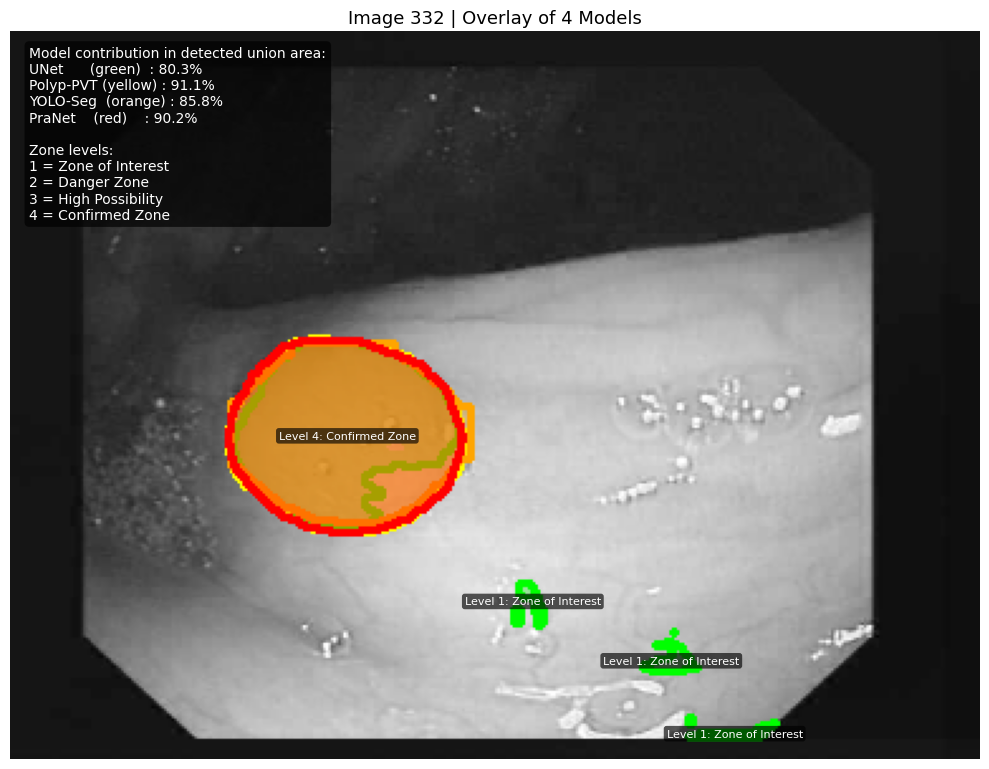

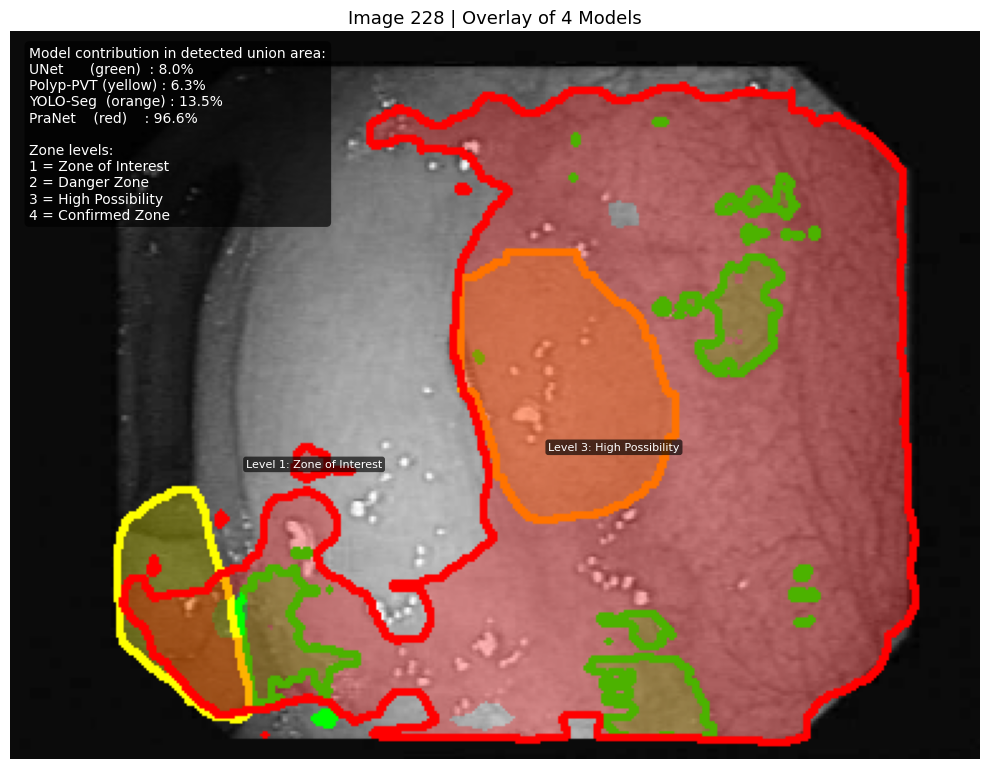

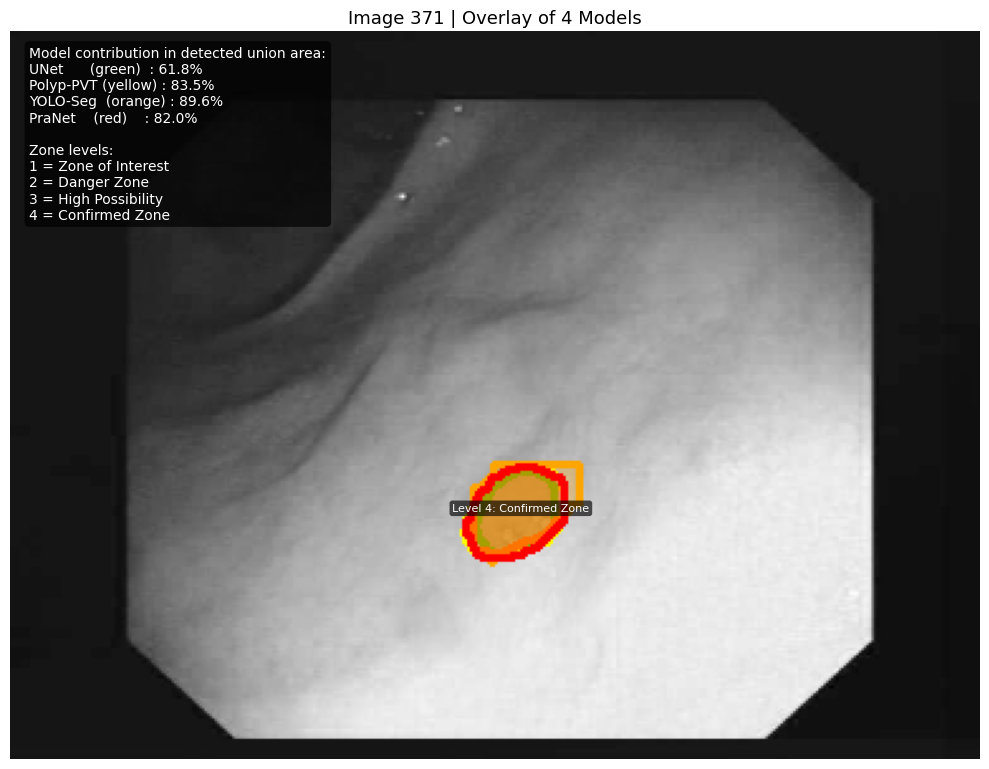

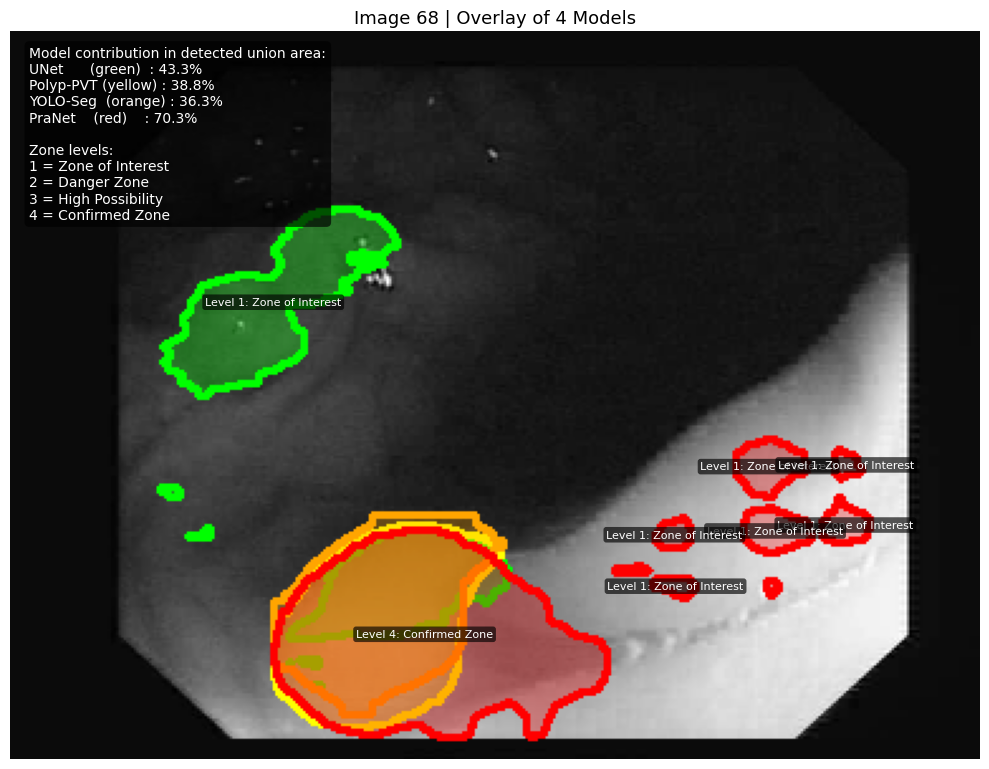

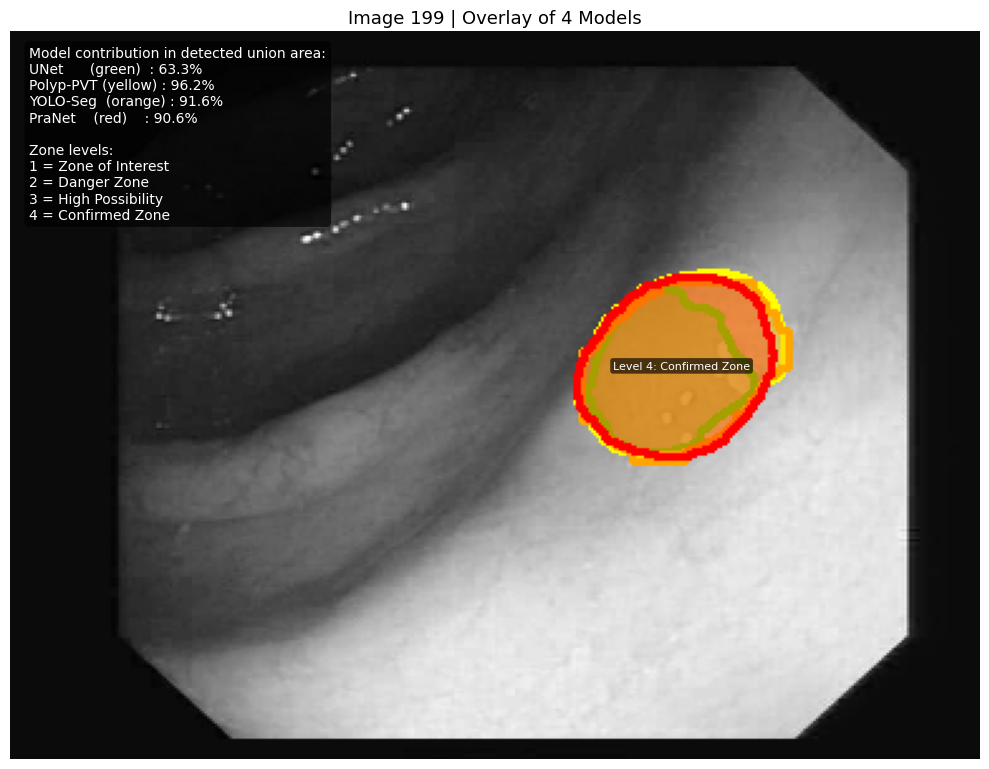

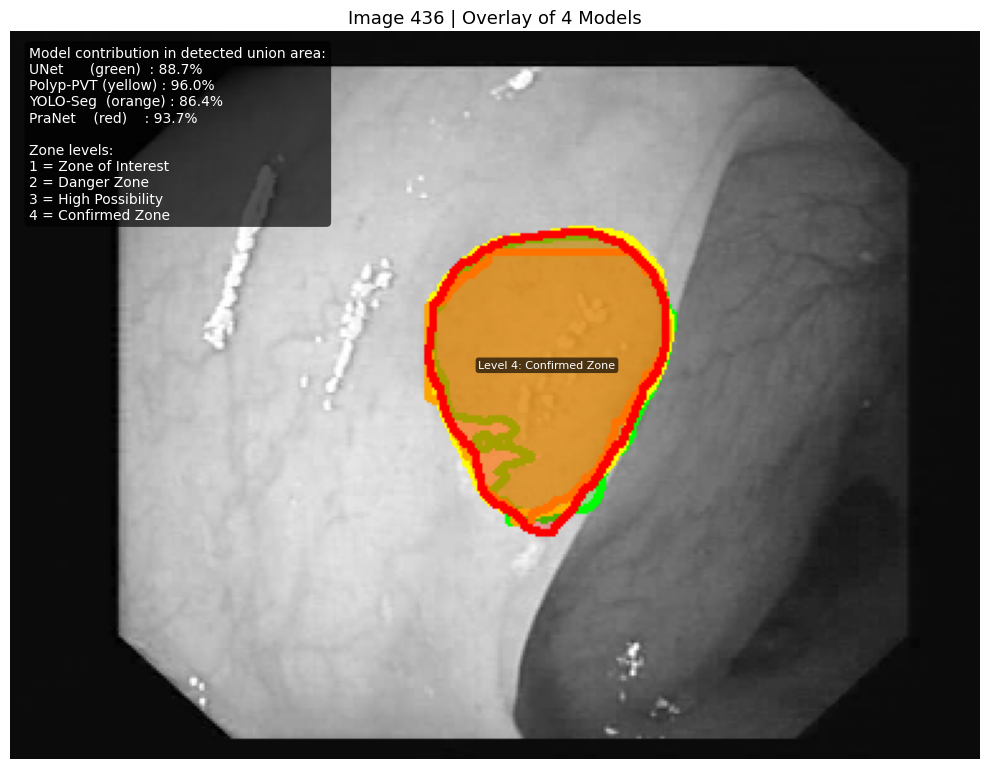

In [ ]:

# Overlay

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

ALPHA = 0.30
NUM_RANDOM_SAMPLES = 6
SEED = None

# precision order
# UNet (0.756) < Polyp-PVT (0.871) < YOLO-Seg (0.873) < PraNet (0.918)
MODEL_SPECS = [
    {"name": "UNet",     "df": unet_df,      "color_rgb": (0, 255, 0)},     # green
    {"name": "PolypPVT", "df": polyppvt_df,  "color_rgb": (255, 255, 0)},   # yellow
    {"name": "YOLO",     "df": yolo_seg_df,  "color_rgb": (255, 165, 0)},   # orange
    {"name": "PraNet",   "df": pranet_df,    "color_rgb": (255, 0, 0)},     # red
]

ZONE_LABELS = {
    1: "Level 1: Zone of Interest",
    2: "Level 2: Danger Zone",
    3: "Level 3: High Possibility",
    4: "Level 4: Confirmed Zone",
}

def normalize_image_name(x):
    x = str(x).strip()
    x = os.path.basename(x)
    x = os.path.splitext(x)[0]
    return x

def find_image_path(images_dir, image_name):
    stem = normalize_image_name(image_name)
    exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]
    for ext in exts:
        p = os.path.join(images_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None

def build_pred_mask_lookup(df):
    lut = {}
    for _, row in df.iterrows():
        key = normalize_image_name(row["image"])
        lut[key] = row["pred_mask"]
    return lut

def ensure_binary_mask(mask, target_hw):
    H, W = target_hw
    mask = np.array(mask)
    if mask.ndim > 2:
        mask = np.squeeze(mask)
    mask = (mask > 0).astype(np.uint8)
    if mask.shape != (H, W):
        mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)
    return mask

def overlay_one_mask(base_rgb, mask_bin, color_rgb, alpha=0.30):
    out = base_rgb.copy().astype(np.float32)
    color = np.array(color_rgb, dtype=np.float32)
    idx = mask_bin > 0
    out[idx] = (1 - alpha) * out[idx] + alpha * color
    return out.astype(np.uint8)

def draw_mask_contour(img_rgb, mask_bin, color_rgb, thickness=2):
    out = img_rgb.copy()
    contours, _ = cv2.findContours(mask_bin.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        cv2.drawContours(out, contours, -1, color_rgb, thickness)
    return out

def compute_model_contributions(mask_dict):

    masks = list(mask_dict.values())
    union_mask = np.zeros_like(masks[0], dtype=np.uint8)
    for m in masks:
        union_mask = np.maximum(union_mask, m.astype(np.uint8))
    union_area = int(union_mask.sum())

    contrib = {}
    for name, m in mask_dict.items():
        area = int(m.sum())
        pct = 100.0 * area / union_area if union_area > 0 else 0.0
        contrib[name] = pct
    return contrib, union_mask, union_area

def annotate_zone_levels(ax, vote_map):

    bin_union = (vote_map > 0).astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bin_union, connectivity=8)

    for comp_id in range(1, num_labels):
        x, y, w, h, area = stats[comp_id]
        if area < 80:
            continue

        comp_mask = (labels == comp_id)
        max_vote = int(vote_map[comp_mask].max())
        label = ZONE_LABELS.get(max_vote, f"Level {max_vote}")
        cx, cy = centroids[comp_id]

        ax.text(
            cx, cy, label,
            color="white",
            fontsize=8,
            ha="center", va="center",
            bbox=dict(facecolor="black", alpha=0.65, edgecolor="none", boxstyle="round,pad=0.25")
        )

def build_sample_overlay(image_name, images_dir):
    img_path = find_image_path(images_dir, image_name)
    if img_path is None:
        return None

    img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    mask_dict = {}
    overlay = img_rgb.copy()

    for spec in MODEL_SPECS:
        key = normalize_image_name(image_name)
        pred_mask = pred_luts[spec["name"]].get(key, None)
        if pred_mask is None:
            pred_mask = np.zeros((H, W), dtype=np.uint8)
        pred_mask = ensure_binary_mask(pred_mask, (H, W))
        mask_dict[spec["name"]] = pred_mask

        overlay = overlay_one_mask(overlay, pred_mask, spec["color_rgb"], alpha=ALPHA)
        overlay = draw_mask_contour(overlay, pred_mask, spec["color_rgb"], thickness=2)

    contrib, union_mask, union_area = compute_model_contributions(mask_dict)

    vote_map = np.zeros((H, W), dtype=np.uint8)
    for m in mask_dict.values():
        vote_map += m.astype(np.uint8)

    return {
        "image_name": normalize_image_name(image_name),
        "img_rgb": img_rgb,
        "overlay": overlay,
        "mask_dict": mask_dict,
        "contrib": contrib,
        "union_area": union_area,
        "vote_map": vote_map,
    }

# lookups
pred_luts = {
    "UNet": build_pred_mask_lookup(unet_df),
    "YOLO": build_pred_mask_lookup(yolo_seg_df),
    "PraNet": build_pred_mask_lookup(pranet_df),
    "PolypPVT": build_pred_mask_lookup(polyppvt_df),
}


common_images = sorted(
    set(pred_luts["UNet"].keys()) &
    set(pred_luts["YOLO"].keys()) &
    set(pred_luts["PraNet"].keys()) &
    set(pred_luts["PolypPVT"].keys())
)

print("Common images available:", len(common_images))

if SEED is not None:
    random.seed(SEED)

sample_images = random.sample(common_images, min(NUM_RANDOM_SAMPLES, len(common_images)))

for image_name in sample_images:
    result = build_sample_overlay(image_name, images_dir)
    if result is None:
        continue

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(result["overlay"])
    ax.set_title(f"Image {result['image_name']} | Overlay of 4 Models", fontsize=13)
    ax.axis("off")

    annotate_zone_levels(ax, result["vote_map"])

    contrib = result["contrib"]

    legend_lines = [
        "Model contribution in detected union area:",
        f"UNet      (green)  : {contrib['UNet']:.1f}%",
        f"Polyp-PVT (yellow) : {contrib['PolypPVT']:.1f}%",
        f"YOLO-Seg  (orange) : {contrib['YOLO']:.1f}%",
        f"PraNet    (red)    : {contrib['PraNet']:.1f}%",
        "",
        "Zone levels:",
        "1 = Zone of Interest",
        "2 = Danger Zone",
        "3 = High Possibility",
        "4 = Confirmed Zone",
    ]

    ax.text(
        0.02, 0.98, "\n".join(legend_lines),
        transform=ax.transAxes,
        fontsize=10,
        va="top", ha="left",
        color="white",
        bbox=dict(facecolor="black", alpha=0.68, edgecolor="none", boxstyle="round,pad=0.35")
    )

    plt.tight_layout()
    plt.show()

## Nuevo

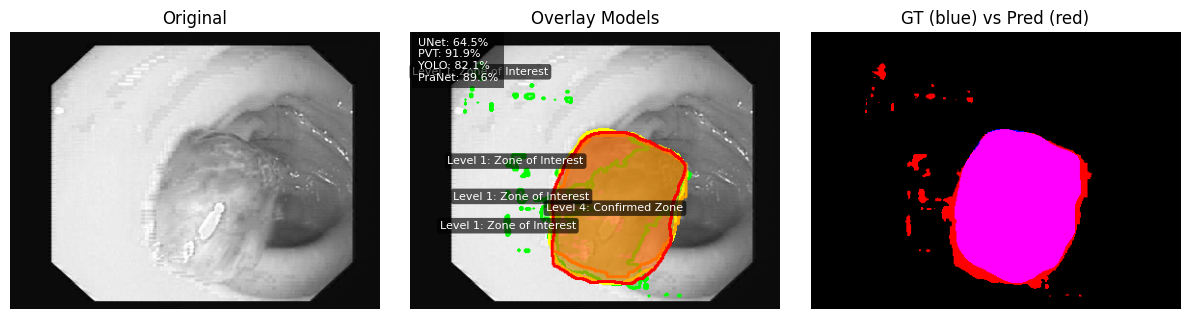

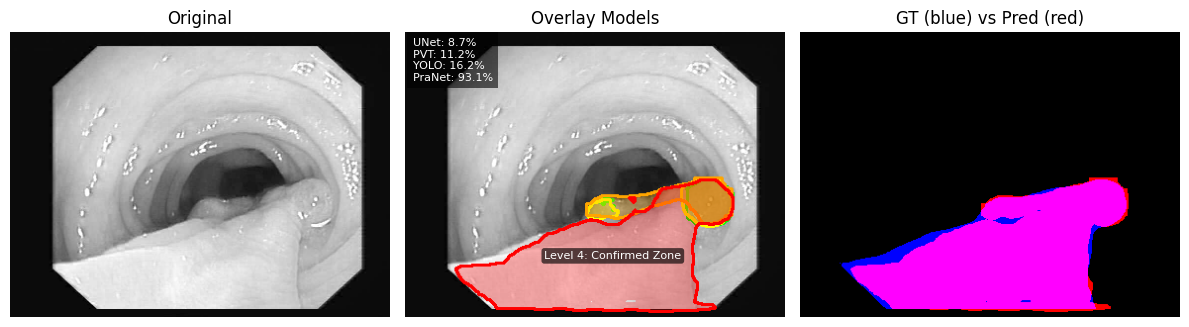

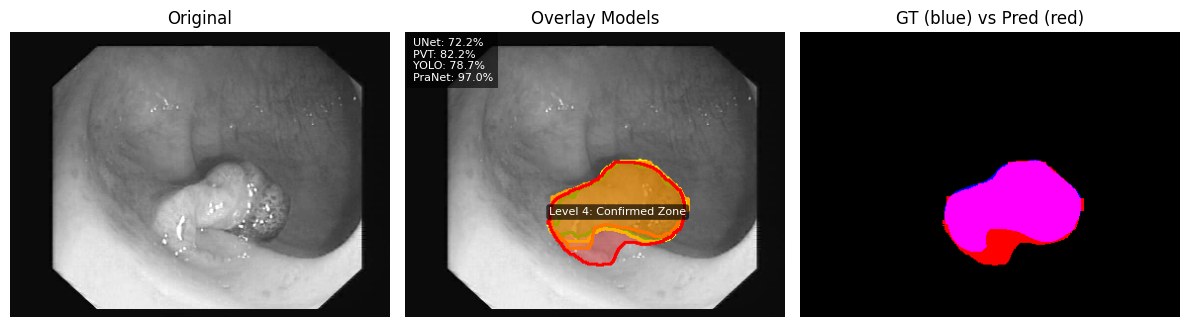

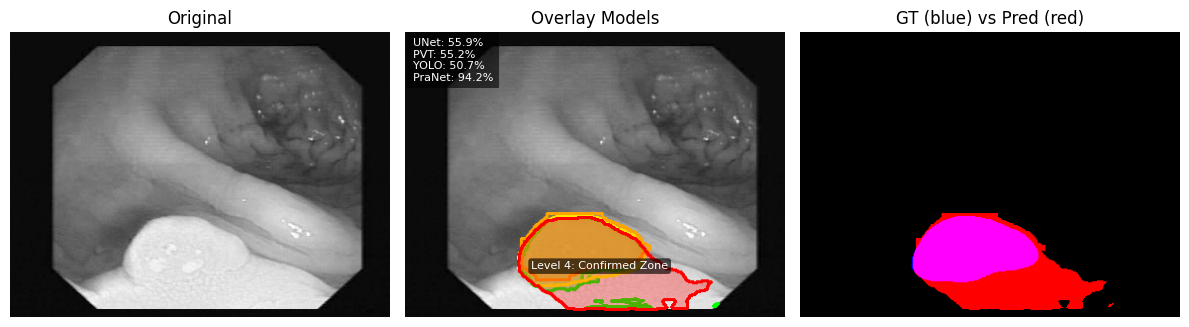

In [ ]:

# Overlay + masks

import matplotlib.pyplot as plt

NUM_RANDOM_SAMPLES = 4

sample_images = random.sample(common_images, min(NUM_RANDOM_SAMPLES, len(common_images)))

for image_name in sample_images:
    result = build_sample_overlay(image_name, images_dir)
    if result is None:
        continue

    img = result["img_rgb"]
    overlay = result["overlay"]
    vote_map = result["vote_map"]

    # mask (OR)
    combined_mask = (vote_map >= 1).astype(np.uint8)

    mask_path = find_mask_path(masks_dir, image_name)
    gt_mask = None
    if mask_path is not None:
        gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if gt is not None:
            gt = cv2.resize(gt, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
            gt_mask = (gt > 127).astype(np.uint8)


    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    #  original
    axs[0].imshow(img)
    axs[0].set_title("Original")
    axs[0].axis("off")

    # overlay
    axs[1].imshow(overlay)
    axs[1].set_title("Overlay Models")
    axs[1].axis("off")

    # masks
    if gt_mask is not None:

        mask_vis = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)

        # GT → blue
        mask_vis[gt_mask == 1] = [0, 0, 255]

        # pred → red
        mask_vis[combined_mask == 1] = [255, 0, 0]

        # intersección → purple
        intersection = (gt_mask == 1) & (combined_mask == 1)
        mask_vis[intersection] = [255, 0, 255]

        axs[2].imshow(mask_vis)
        axs[2].set_title("GT (blue) vs Pred (red)")
    else:
        axs[2].imshow(combined_mask, cmap="gray")
        axs[2].set_title("Pred Mask")

    axs[2].axis("off")

    #  levels
    annotate_zone_levels(axs[1], vote_map)

    contrib = result["contrib"]
    text = (
        f"UNet: {contrib['UNet']:.1f}%\n"
        f"PVT: {contrib['PolypPVT']:.1f}%\n"
        f"YOLO: {contrib['YOLO']:.1f}%\n"
        f"PraNet: {contrib['PraNet']:.1f}%"
    )

    axs[1].text(
        0.02, 0.98, text,
        transform=axs[1].transAxes,
        fontsize=8,
        va="top",
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none")
    )

    plt.tight_layout()
    plt.show()

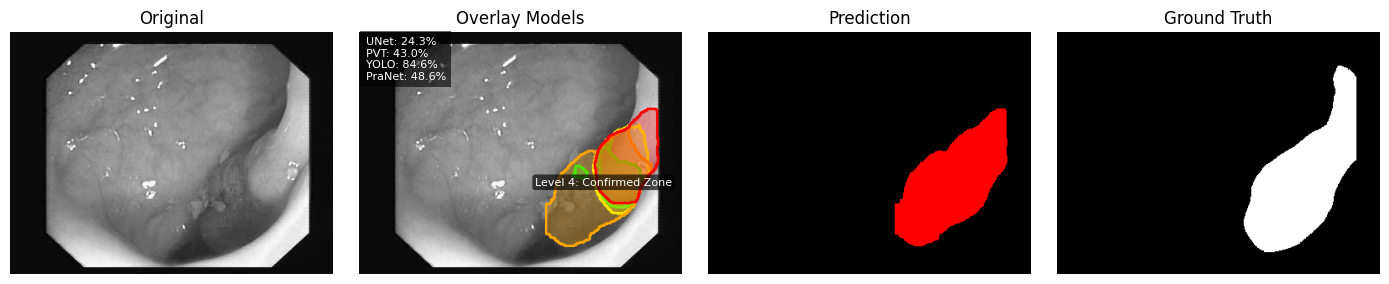

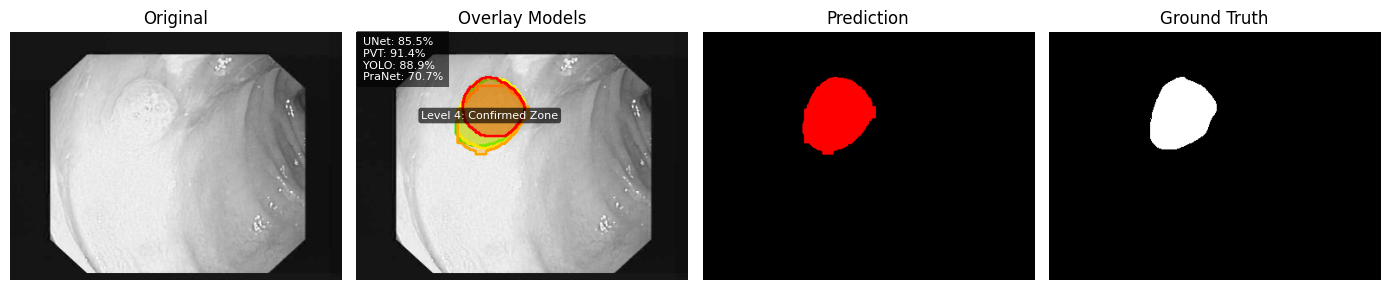

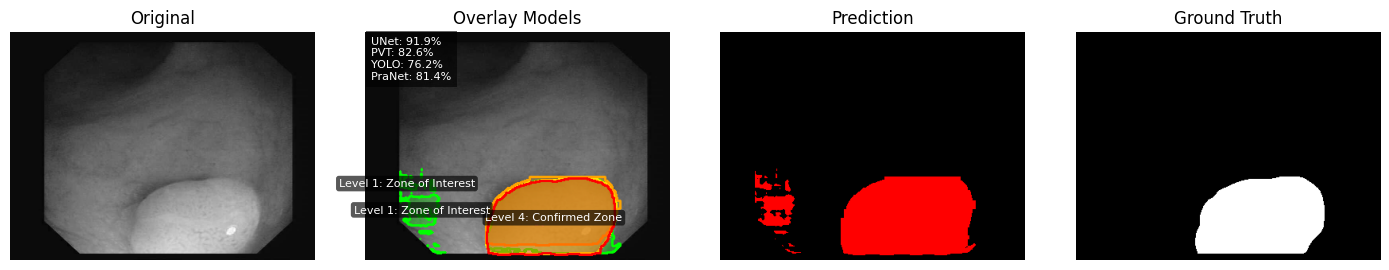

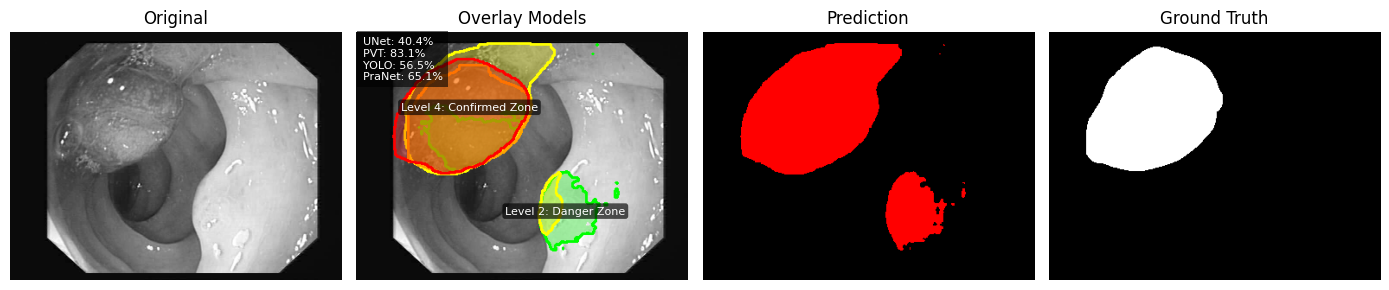

In [ ]:

# Overlay + masks
import matplotlib.pyplot as plt

NUM_RANDOM_SAMPLES = 4

sample_images = random.sample(common_images, min(NUM_RANDOM_SAMPLES, len(common_images)))

for image_name in sample_images:
    result = build_sample_overlay(image_name, images_dir)
    if result is None:
        continue

    img = result["img_rgb"]
    overlay = result["overlay"]
    vote_map = result["vote_map"]


    combined_mask = (vote_map >= 1).astype(np.uint8)


    mask_path = find_mask_path(masks_dir, image_name)
    gt_mask = None
    if mask_path is not None:
        gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if gt is not None:
            gt = cv2.resize(gt, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
            gt_mask = (gt > 127).astype(np.uint8)


    fig, axs = plt.subplots(1, 4, figsize=(14, 4))

    # original
    axs[0].imshow(img)
    axs[0].set_title("Original")
    axs[0].axis("off")

    #  overlay
    axs[1].imshow(overlay)
    axs[1].set_title("Overlay Models")
    axs[1].axis("off")

    #  predicción
    pred_vis = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    pred_vis[combined_mask == 1] = [255, 0, 0]

    axs[2].imshow(pred_vis)
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    #  GT
    if gt_mask is not None:
        gt_vis = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
        gt_vis[gt_mask == 1] = [255, 255, 255]

        axs[3].imshow(gt_vis)
        axs[3].set_title("Ground Truth")
    else:
        axs[3].imshow(np.zeros_like(pred_vis))
        axs[3].set_title("GT (not found)")

    axs[3].axis("off")


    annotate_zone_levels(axs[1], vote_map)


    contrib = result["contrib"]
    text = (
        f"UNet: {contrib['UNet']:.1f}%\n"
        f"PVT: {contrib['PolypPVT']:.1f}%\n"
        f"YOLO: {contrib['YOLO']:.1f}%\n"
        f"PraNet: {contrib['PraNet']:.1f}%"
    )

    axs[1].text(
        0.02, 0.98, text,
        transform=axs[1].transAxes,
        fontsize=8,
        va="top",
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none")
    )

    plt.tight_layout()
    plt.show()